# 🫁 Astım Ses Sınıflandırıcı — Kaggle GPU Edition

**Bu notebook'u çalıştırmadan önce sağ panelde şunları ekle:**
1. `+ Add Data` → `respiratory-sound-database` (ICBHI 2017)
2. `+ Add Data` → `coswara-data` (Coswara)
3. Sağ üstte `Session options` → `Accelerator: GPU P100` seç

---

## Hücre 1 — Kurulum

In [1]:
!pip install onnx onnxruntime --quiet

import os, random, time
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torchaudio
import torchaudio.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Cihaz: {DEVICE}')
if DEVICE == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 85.9 MB/s eta 0:00:00:00:0100:01
✅ Cihaz: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## Hücre 2 — Kaggle Yol Tespiti

In [2]:
# Kaggle'da dataset'ler /kaggle/input/ altına mount edilir
# Hangi klasör adıyla geldiğini otomatik tespit edelim

KAGGLE_INPUT = Path('/kaggle/input')
OUTPUT_DIR   = Path('/kaggle/working/output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('📁 /kaggle/input/ içeriği:')
for d in sorted(KAGGLE_INPUT.iterdir()):
    sub = list(d.iterdir())[:3]
    print(f'  {d.name}/')
    for s in sub:
        print(f'    {s.name}')

📁 /kaggle/input/ içeriği:
  datasets/
    husninm
    janashreeananthan


In [3]:
# ============================================================
# Kaggle Input Yapısına Göre Güncellenmiş Yollar
# ============================================================

def find_dir_recursive(base: Path, keywords: list) -> Path:
    """Alt klasörlerde keyword içeren ilk dizini bulur"""
    for d in base.rglob('*'):
        if d.is_dir() and any(kw.lower() in d.name.lower() for kw in keywords):
            return d
    raise FileNotFoundError(f'{keywords} içeren klasör bulunamadı in {base}')

# Veri setlerin /kaggle/input/datasets altında olduğu için rglob kullanıyoruz
ICBHI_ROOT   = find_dir_recursive(KAGGLE_INPUT, ['respiratory', 'icbhi', 'lung'])
COSWARA_ROOT = find_dir_recursive(KAGGLE_INPUT, ['coswara'])

# ICBHI içinde audio ve annotation dosyalarını netleştirelim
ICBHI_AUDIO  = next(ICBHI_ROOT.rglob('audio'), None) or ICBHI_ROOT
ICBHI_ANNOT  = ICBHI_ROOT # .txt dosyaları genellikle ana klasörde veya audio yanındadır

print(f'✅ ICBHI root  : {ICBHI_ROOT}')
print(f'✅ ICBHI audio : {ICBHI_AUDIO}')
print(f'✅ Coswara root: {COSWARA_ROOT}')

# Parametre sabitleri (Aynı kalabilir)
SAMPLE_RATE  = 22050
SEGMENT_LEN  = 5.0
N_MELS       = 128
BATCH_SIZE   = 32   
EPOCHS       = 40
LR           = 1e-4
NUM_CLASSES  = 4
CLASS_NAMES  = ['normal', 'wheeze', 'crackle', 'cough']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

✅ ICBHI root  : /kaggle/input/datasets/husninm/icbhi-2017-challenge
✅ ICBHI audio : /kaggle/input/datasets/husninm/icbhi-2017-challenge
✅ Coswara root: /kaggle/input/datasets/janashreeananthan/coswara


## Hücre 3 — ICBHI Parse

In [4]:
def parse_icbhi(audio_dir: Path, annot_dir: Path) -> pd.DataFrame:
    records = []
    txt_files = list(annot_dir.rglob('*.txt'))
    print(f'Bulunan .txt dosyası: {len(txt_files)}')

    for txt_file in txt_files:
        patient_id = txt_file.stem
        # audio klasöründe eşleşen wav'ı bul
        wav_candidates = list(audio_dir.rglob(f'{patient_id}.wav'))
        if not wav_candidates:
            continue
        wav_file = wav_candidates[0]

        with open(txt_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 4:
                    continue
                try:
                    start   = float(parts[0])
                    end     = float(parts[1])
                    crackle = int(parts[2])
                    wheeze  = int(parts[3])
                except ValueError:
                    continue

                if wheeze:
                    label = 'wheeze'
                elif crackle:
                    label = 'crackle'
                else:
                    label = 'normal'

                records.append({
                    'filepath': str(wav_file),
                    'start': start, 'end': end,
                    'label': label, 'source': 'icbhi'
                })

    df = pd.DataFrame(records)
    print(f'\n📊 ICBHI toplam segment: {len(df)}')
    print(df['label'].value_counts().to_string())
    return df

icbhi_df = parse_icbhi(ICBHI_AUDIO, ICBHI_ANNOT)
icbhi_df.head()

Bulunan .txt dosyası: 922

📊 ICBHI toplam segment: 6898
label
normal     3642
crackle    1864
wheeze     1392


,filepath,start,end,label,source
0,/kaggle/input/datasets/husninm/icbhi-2017-chal...,0.036,2.436,normal,icbhi
1,/kaggle/input/datasets/husninm/icbhi-2017-chal...,2.436,5.250,normal,icbhi
2,/kaggle/input/datasets/husninm/icbhi-2017-chal...,5.250,8.422,normal,icbhi
3,/kaggle/input/datasets/husninm/icbhi-2017-chal...,8.422,11.222,normal,icbhi
4,/kaggle/input/datasets/husninm/icbhi-2017-chal...,11.222,13.807,normal,icbhi


## Hücre 4 — Coswara Parse

In [5]:
import shutil
from pathlib import Path

input_root = Path("/kaggle/input/datasets/janashreeananthan/coswara")
work_root  = Path("/kaggle/working/coswara")

work_root.mkdir(parents=True, exist_ok=True)

for d in input_root.iterdir():
    if d.is_dir() and d.name.startswith("202"):
        target_dir = work_root / d.name
        target_dir.mkdir(exist_ok=True)

        for file in d.glob("*"):
            shutil.copy(file, target_dir)

print("Kopyalama tamam ✅")

Kopyalama tamam ✅


In [6]:
import os

for d in work_root.iterdir():
    parts = sorted(d.glob("*.tar.gz.*"))
    if not parts:
        continue

    tar_path = d / f"{d.name}.tar.gz"

    # birleştir
    with open(tar_path, "wb") as outfile:
        for p in parts:
            with open(p, "rb") as infile:
                outfile.write(infile.read())

    print(f"{d.name} birleştirildi")

    # extract
    os.system(f"tar -xzf {tar_path} -C {d}")
    print(f"{d.name} extract edildi")

20200814 birleştirildi
20200814 extract edildi
20200418 birleştirildi
20200418 extract edildi
20200505 birleştirildi
20200505 extract edildi
20200803 birleştirildi
20200803 extract edildi
20200525 birleştirildi
20200525 extract edildi
20200824 birleştirildi
20200824 extract edildi
20200604 birleştirildi
20200604 extract edildi
20200419 birleştirildi
20200419 extract edildi
20200424 birleştirildi
20200424 extract edildi
20200502 birleştirildi
20200502 extract edildi
20200504 birleştirildi
20200504 extract edildi
20200415 birleştirildi
20200415 extract edildi
20200430 birleştirildi
20200430 extract edildi
20200413 birleştirildi
20200413 extract edildi
20200416 birleştirildi


tar: ./20200416/ewjgkt6HqIQ24vpCKFBISsgr5gJ3/counting-normal.wav: Wrote only 2560 of 10240 bytes
tar: ./20200416/ewjgkt6HqIQ24vpCKFBISsgr5gJ3/metadata.json: Cannot write: No space left on device
tar: ./20200416/ewjgkt6HqIQ24vpCKFBISsgr5gJ3/vowel-o.wav: Cannot write: No space left on device
tar: ./20200416/ewjgkt6HqIQ24vpCKFBISsgr5gJ3/vowel-a.wav: Cannot write: No space left on device
tar: ./20200416/ewjgkt6HqIQ24vpCKFBISsgr5gJ3/vowel-e.wav: Cannot write: No space left on device
tar: ./20200416/ewjgkt6HqIQ24vpCKFBISsgr5gJ3/breathing-shallow.wav: Cannot write: No space left on device
tar: ./20200416/ewjgkt6HqIQ24vpCKFBISsgr5gJ3/counting-fast.wav: Cannot write: No space left on device
tar: ./20200416/ewjgkt6HqIQ24vpCKFBISsgr5gJ3/breathing-deep.wav: Cannot write: No space left on device
tar: ./20200416/ewjgkt6HqIQ24vpCKFBISsgr5gJ3/cough-heavy.wav: Cannot write: No space left on device
tar: ./20200416/ewjgkt6HqIQ24vpCKFBISsgr5gJ3/cough-shallow.wav: Cannot write: No space left on device
tar:

20200416 extract edildi


OSError: [Errno 28] No space left on device

In [7]:
# extract sonrası
for p in parts:
    os.remove(p)  # parçaları sil

os.remove(tar_path)  # birleşmiş tar.gz sil

In [8]:
coswara_df = parse_coswara(work_root)

NameError: name 'parse_coswara' is not defined

In [9]:
import pandas as pd
from pathlib import Path

def parse_coswara_final(extracted_dir: Path) -> pd.DataFrame:
    records = []
    
    # 1. Metadata'yı Senin Yolunda Bul
    # combined_data.csv genellikle ana klasörde olur
    meta_path = next(extracted_dir.rglob('combined_data.csv'), None)
    meta_dict = {}
    if meta_path:
        meta = pd.read_csv(meta_path).drop_duplicates(subset=['id'])
        meta_dict = meta.set_index('id').to_dict('index')
        print(f"✅ Metadata yüklendi: {len(meta)} hasta.")

    # 2. .wav Dosyalarını Senin Yolunda Ara (Klasör yapısından bağımsız)
    print(f"🔍 Tarama yapılıyor: {extracted_dir}")
    # rglob('*') ile tüm alt klasörlere (2020... vb.) girer
    all_wavs = list(extracted_dir.rglob('*.wav'))
    
    for wav_path in all_wavs:
        fname = wav_path.name.lower()
        p_id = wav_path.parent.name # Hasta ID'si klasör adıdır
        
        # Taslağındaki semptomlara göre etiketleme
        if 'cough' in fname:
            label = 'cough'
        elif 'breathing' in fname:
            user = meta_dict.get(p_id, {})
            # Astım hastası ise 'wheeze' (hırıltı), değilse 'normal'
            label = 'wheeze' if str(user.get('asthma', 'n')).lower() == 'y' else 'normal'
        else:
            continue

        records.append({
            'filepath': str(wav_path),
            'label': label,
            'start': 0.0,
            'end': -1.0,
            'source': 'coswara'
        })

    # 3. Boş Liste Kontrolü (Hata almamak için)
    if not records:
        print(f"❌ HATA: {extracted_dir} içinde hiç .wav dosyası bulunamadı!")
        print("Lütfen dosyaların gerçekten bu klasöre ayıklandığından emin ol.")
        return pd.DataFrame()

    df = pd.DataFrame(records)
    print(f"🚀 BAŞARILI: Coswara'dan {len(df)} kayıt toplandı.")
    print(df['label'].value_counts())
    return df

# SENİN YOLLARINLA ÇALIŞTIRALIM
work_root = Path("/kaggle/working/coswara")
coswara_df = parse_coswara_final(work_root)

🔍 Tarama yapılıyor: /kaggle/working/coswara
🚀 BAŞARILI: Coswara'dan 4083 kayıt toplandı.
label
normal    2042
cough     2041
Name: count, dtype: int64


## Hücre 5 — Birleştir & Split

In [10]:
full_df = pd.concat([icbhi_df, coswara_df], ignore_index=True)
full_df['label_idx'] = full_df['label'].map(CLASS_TO_IDX)

print(f'Toplam kayıt: {len(full_df)}')
print('\nSınıf dağılımı:')
vc = full_df['label'].value_counts()
for cls, cnt in vc.items():
    bar = '█' * (cnt // 50)
    print(f'  {cls:10s} {cnt:5d}  {bar}')

train_df, temp_df = train_test_split(
    full_df, test_size=0.3, stratify=full_df['label_idx'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label_idx'], random_state=42
)

print(f'\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

train_df.to_csv(OUTPUT_DIR / 'train.csv', index=False)
val_df.to_csv(OUTPUT_DIR / 'val.csv', index=False)
test_df.to_csv(OUTPUT_DIR / 'test.csv', index=False)
print('✅ Split kaydedildi')

Toplam kayıt: 10981

Sınıf dağılımı:
  normal      5684  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  cough       2041  ████████████████████████████████████████
  crackle     1864  █████████████████████████████████████
  wheeze      1392  ███████████████████████████

Train: 7686 | Val: 1647 | Test: 1648
✅ Split kaydedildi


## Hücre 6 — Dataset & DataLoader

In [11]:
class RespiratoryDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df      = df.reset_index(drop=True)
        self.augment = augment
        self.seg_len = int(SAMPLE_RATE * SEGMENT_LEN)
        self.mel_tf  = T.MelSpectrogram(
            sample_rate=SAMPLE_RATE, n_fft=1024, hop_length=512,
            n_mels=N_MELS, f_min=50, f_max=8000
        )
        self.to_db   = T.AmplitudeToDB(top_db=80)

    def load_audio(self, row):
        wav, sr = torchaudio.load(row['filepath'])
        if wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)
        if sr != SAMPLE_RATE:
            wav = T.Resample(sr, SAMPLE_RATE)(wav)
        if row['end'] > 0:
            s = int(row['start'] * SAMPLE_RATE)
            e = int(row['end']   * SAMPLE_RATE)
            wav = wav[:, s:e]
        if wav.shape[1] < self.seg_len:
            reps = (self.seg_len // wav.shape[1]) + 1
            wav  = wav.repeat(1, reps)
        return wav[:, :self.seg_len]

    def augment_wav(self, wav):
        if random.random() < 0.5:
            wav = wav + torch.randn_like(wav) * 0.005
        if random.random() < 0.5:
            shift = random.randint(-int(0.5 * SAMPLE_RATE), int(0.5 * SAMPLE_RATE))
            wav   = torch.roll(wav, shift, dims=1)
        if random.random() < 0.3:
            wav = wav * random.uniform(0.8, 1.2)
        return wav

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            wav = self.load_audio(row)
        except Exception:
            # Bozuk dosya varsa sıfır tensor döndür
            wav = torch.zeros(1, self.seg_len)

        if self.augment:
            wav = self.augment_wav(wav)

        mel = self.mel_tf(wav)
        mel = self.to_db(mel)
        mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
        mel = mel.repeat(3, 1, 1)   # (3, 128, T)

        return mel, torch.tensor(int(row['label_idx']), dtype=torch.long)


# num_workers=4 GPU'da çok daha hızlı
train_ds = RespiratoryDataset(train_df, augment=True)
val_ds   = RespiratoryDataset(val_df,   augment=False)
test_ds  = RespiratoryDataset(test_df,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

mel, lbl = train_ds[0]
print(f'✅ Mel shape : {mel.shape}')   # (3, 128, 216)
print(f'✅ Label     : {CLASS_NAMES[lbl]}')
print(f'Train batch : {len(train_loader)}')

✅ Mel shape : torch.Size([3, 128, 216])
✅ Label     : normal
Train batch : 241


## Hücre 7 — Model

In [12]:
class RespiratoryClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        backbone        = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.features   = backbone.features
        self.avgpool    = backbone.avgpool
        in_feats        = backbone.classifier[1].in_features  # 1280
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_feats, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


model = RespiratoryClassifier(NUM_CLASSES).to(DEVICE)

# Sadece son katmanları eğit (ilk 5 epoch) → sonra tümünü aç
for param in model.features.parameters():
    param.requires_grad = False

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Toplam: {total:,} | Eğitilecek: {trainable:,}')

dummy = torch.randn(2, 3, N_MELS, 216).to(DEVICE)
print(f'Forward test: {model(dummy).shape}')  # (2, 4)
print('✅ Model hazır')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 151MB/s]


Toplam: 4,336,512 | Eğitilecek: 328,964
Forward test: torch.Size([2, 4])
✅ Model hazır


## Hücre 8 — Loss & Optimizer

In [13]:
class_weights = compute_class_weight(
    'balanced', classes=np.arange(NUM_CLASSES), y=train_df['label_idx'].values
)
class_weights[1] *= 1.8   # ← bu satır dışarıda olmalı, burada doğru

cw_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('Sınıf ağırlıkları:')
for name, w in zip(CLASS_NAMES, class_weights):
    print(f'  {name:10s}: {w:.3f}')

criterion = nn.CrossEntropyLoss(weight=cw_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print('✅ Hazır')

Sınıf ağırlıkları:
  normal    : 0.483
  wheeze    : 3.551
  crackle   : 1.472
  cough     : 1.345
✅ Hazır


## Hücre 9 — Eğitim (2 Aşamalı)

In [14]:
UNFREEZE_EPOCH = 5   # Bu epoch'tan sonra tüm katmanlar açılır

def run_epoch(model, loader, optimizer, criterion, device, is_train):
    model.train() if is_train else model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            preds = outputs.argmax(1)
            total_loss  += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, f1


history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
best_val_f1   = 0.0
best_path     = OUTPUT_DIR / 'best_model.pth'

print(f'Eğitim başlıyor — {EPOCHS} epoch | GPU: {DEVICE}')
print(f'İlk {UNFREEZE_EPOCH} epoch: sadece classifier katmanı eğitiliyor')
print(f'Epoch {UNFREEZE_EPOCH}+  : tüm model fine-tune ediliyor\n')
print(f'{"Ep":>3} | {"TrLoss":>7} | {"TrF1":>6} | {"VlLoss":>7} | {"VlF1":>6} | {"LR":>8} | {"Süre":>5}')
print('-' * 55)

for epoch in range(1, EPOCHS + 1):
    # Aşama 2: backbone'u aç
    if epoch == UNFREEZE_EPOCH + 1:
        for param in model.features.parameters():
            param.requires_grad = True
        # Backbone için daha düşük LR
        optimizer = torch.optim.AdamW([
            {'params': model.features.parameters(),   'lr': LR * 0.1},
            {'params': model.classifier.parameters(), 'lr': LR}
        ], weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS - UNFREEZE_EPOCH, eta_min=1e-6
        )
        print(f'\n🔓 Epoch {epoch}: Backbone açıldı, full fine-tuning başlıyor\n')

    t0 = time.time()
    tr_loss, tr_f1 = run_epoch(model, train_loader, optimizer, criterion, DEVICE, is_train=True)
    vl_loss, vl_f1 = run_epoch(model, val_loader,   optimizer, criterion, DEVICE, is_train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)

    lr  = optimizer.param_groups[0]['lr']
    sec = int(time.time() - t0)
    flag = ' 💾' if vl_f1 > best_val_f1 else ''

    print(f'{epoch:>3} | {tr_loss:>7.4f} | {tr_f1:>6.4f} | {vl_loss:>7.4f} | {vl_f1:>6.4f} | {lr:>8.2e} | {sec:>4}s{flag}')

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        torch.save(model.state_dict(), best_path)

print(f'\n✅ Eğitim tamamlandı. En iyi Val F1: {best_val_f1:.4f}')

Eğitim başlıyor — 40 epoch | GPU: cuda
İlk 5 epoch: sadece classifier katmanı eğitiliyor
Epoch 5+  : tüm model fine-tune ediliyor

 Ep |  TrLoss |   TrF1 |  VlLoss |   VlF1 |       LR |  Süre
-------------------------------------------------------
  1 |  1.1190 | 0.3506 |  0.9178 | 0.3631 | 9.98e-05 |   92s 💾
  2 |  0.8983 | 0.4788 |  0.8328 | 0.4616 | 9.94e-05 |   83s 💾
  3 |  0.8476 | 0.5181 |  0.7981 | 0.4792 | 9.86e-05 |   82s 💾
  4 |  0.8290 | 0.5203 |  0.7833 | 0.5035 | 9.76e-05 |   82s 💾
  5 |  0.8086 | 0.5354 |  0.7658 | 0.5166 | 9.62e-05 |   83s 💾

🔓 Epoch 6: Backbone açıldı, full fine-tuning başlıyor

  6 |  0.7887 | 0.5431 |  0.7020 | 0.5721 | 9.98e-06 |   86s 💾
  7 |  0.7299 | 0.5764 |  0.6701 | 0.5924 | 9.93e-06 |   86s 💾
  8 |  0.7111 | 0.5896 |  0.6523 | 0.6219 | 9.84e-06 |   86s 💾
  9 |  0.6847 | 0.6022 |  0.6248 | 0.6220 | 9.71e-06 |   86s 💾
 10 |  0.6574 | 0.6175 |  0.6074 | 0.6338 | 9.55e-06 |   86s 💾
 11 |  0.6458 | 0.6271 |  0.5925 | 0.6356 | 9.36e-06 |   86s 💾
 12

## Hücre 10 — Grafik & Test

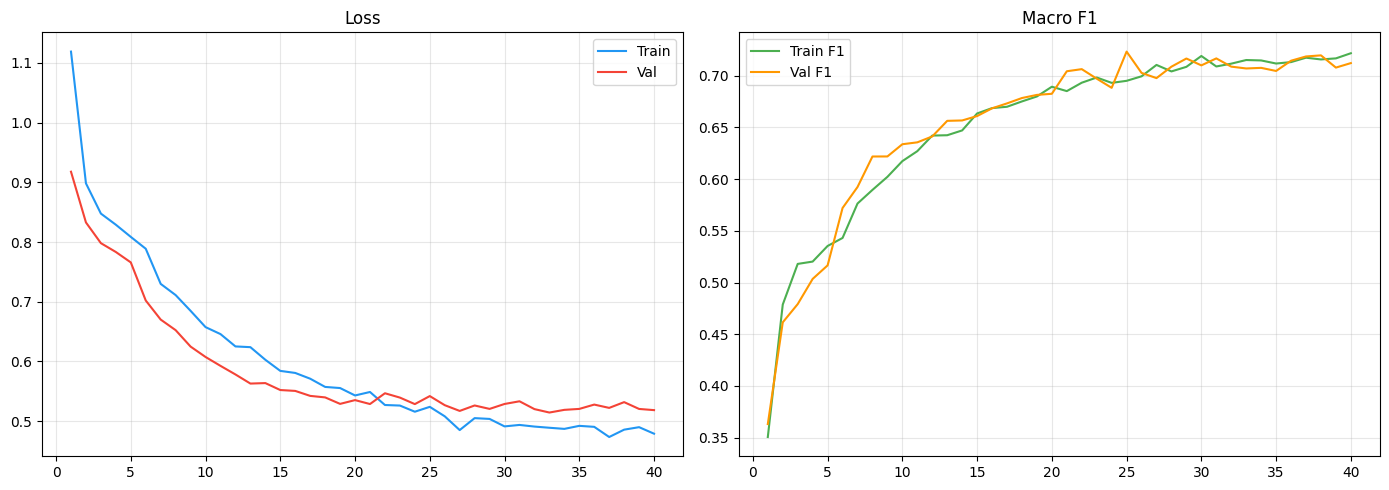


📊 Test Seti Raporu:
              precision    recall  f1-score   support

      normal       0.87      0.60      0.71       853
      wheeze       0.59      0.74      0.66       209
     crackle       0.46      0.77      0.58       280
       cough       0.90      0.98      0.93       306

    accuracy                           0.72      1648
   macro avg       0.71      0.77      0.72      1648
weighted avg       0.77      0.72      0.72      1648



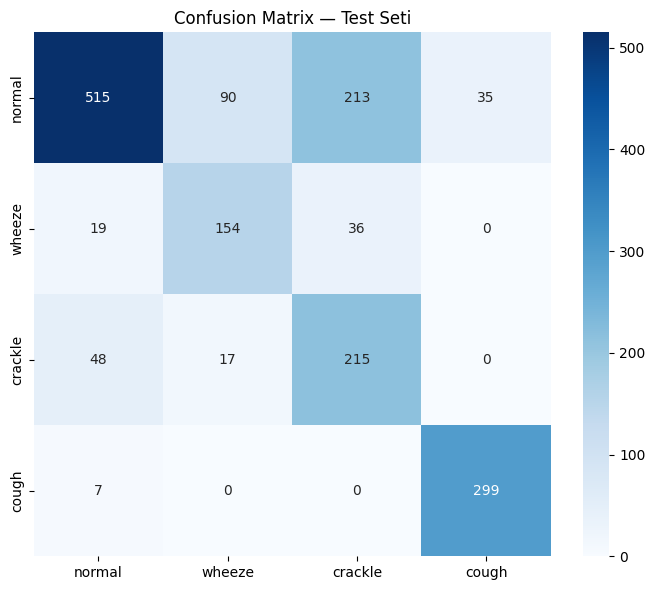

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history['train_loss']) + 1)

ax1.plot(ep, history['train_loss'], label='Train', color='#2196F3')
ax1.plot(ep, history['val_loss'],   label='Val',   color='#F44336')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history['train_f1'], label='Train F1', color='#4CAF50')
ax2.plot(ep, history['val_f1'],   label='Val F1',   color='#FF9800')
ax2.set_title('Macro F1'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'curves.png', dpi=150)
plt.show()

# Test değerlendirmesi
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        preds = model(inputs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print('\n📊 Test Seti Raporu:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Test Seti')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## Hücre 11 — ONNX Export

In [16]:
!pip install onnxscript onnxruntime onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.5 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 15.2 MB/s eta 0:00:00


In [17]:
import onnx, onnxruntime as ort

onnx_path = OUTPUT_DIR / 'respiratory_classifier.onnx'

model.load_state_dict(torch.load(best_path, map_location='cpu'))
model.eval().cpu()

dummy = torch.randn(1, 3, N_MELS, 216)

torch.onnx.export(
    model, dummy, str(onnx_path),
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=['mel_spectrogram'],
    output_names=['class_logits'],
    dynamic_axes={'mel_spectrogram': {0: 'batch'}, 'class_logits': {0: 'batch'}}
)

onnx.checker.check_model(onnx.load(str(onnx_path)))
size_mb = os.path.getsize(onnx_path) / 1e6
print(f'✅ ONNX model: {size_mb:.1f} MB')

# Hız testi
sess    = ort.InferenceSession(str(onnx_path))
inp     = np.random.randn(1, 3, N_MELS, 216).astype(np.float32)
t0      = time.time()
for _ in range(50):
    out = sess.run(None, {'mel_spectrogram': inp})
avg_ms = (time.time() - t0) / 50 * 1000
print(f'⚡ Ortalama inference süresi: {avg_ms:.1f} ms')
print(f'\nSınıf tahminleri için label mapping:')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {i} → {name}')
print(f'\n✅ Flutter projesine ekleyebilirsin: {onnx_path}')

/tmp/ipykernel_55/2238534084.py:10: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0325 10:14:09.070000 55 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0325 10:14:10.068000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned

[torch.onnx] Obtain model graph for `RespiratoryClassifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `RespiratoryClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Runtim

Applied 99 of general pattern rewrite rules.
✅ ONNX model: 0.6 MB
⚡ Ortalama inference süresi: 7.1 ms

Sınıf tahminleri için label mapping:
  0 → normal
  1 → wheeze
  2 → crackle
  3 → cough

✅ Flutter projesine ekleyebilirsin: /kaggle/working/output/respiratory_classifier.onnx


---
## 📥 Dosyaları İndir
Eğitim bitince sol panelde `output/` klasöründen şunları indir:
- `best_model.pth` — PyTorch model ağırlıkları (yedek)
- `respiratory_classifier.onnx` — Flutter'a gömmek için
- `confusion_matrix.png` — model performansı
- `curves.png` — eğitim grafikleri